# Comparison with `Source-Extractor` (formerly `SExtractor`)

`Source-Extractor` (formerly `SExtractor`) is a popular astronomical image reduction software that runs in the command line. While both `photutils` and `Source-Extractor` serve similar purposes, they do so in subtly different ways and have fundamentally different design principles. Nonetheless, the end-result should be extremely similar, regardless of the choice of software, assuming both are correct.

In this notebook, I compare the results of `opticam` (`photutils`-based) to `Source-Extractor` and show that they are equivalent when configured similarly. For simplicity, image calibrations are omitted from this comparison; instead, `opticam`'s calibration methods are test in a [separate notebook](test_error_propagation.ipynb).

## A test image

For this example, I'll use an OPTICAM-MX image of V709 Cas:

In [1]:
from pathlib import Path

from astropy.io import fits
import numpy as np

data_path = Path('sextractor_comparison')

data, header = fits.getdata(data_path / 'V709_Cas_image.fits', header=True)
data = np.asarray(data, dtype=np.float64)

print(repr(header))

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1024 / length of data axis 1                          
NAXIS2  =                 1024 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
EXPOSURE=                   3. / Single frame exposure time (s)                 
GAIN    =                   1. / Electronic gain (e-/ADU)                       
EXPCOAD =                   

As we can see, this image was taken in the 2x2 binning mode, and so has a resolution of 1024x1024. Let's take a look at the image:

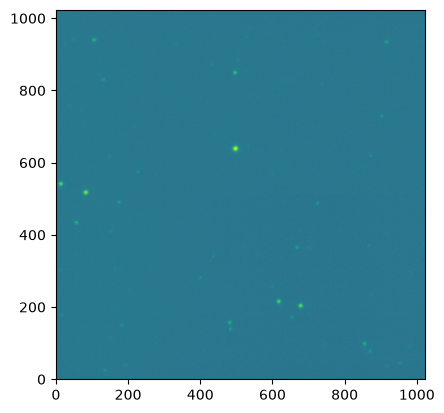

In [2]:
from astropy.visualization import simple_norm
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

ax.imshow(data, origin='lower', norm=simple_norm(data, stretch='log'))

plt.show()

Instead of using `opticam.Reducer`, since we're only working with a single image, we'll compute the image background, identify sources, and perform photometry manually (using `opticam`'s default values).

By default, `opticam` uses [photutils.segmentation.SourceFinder](https://photutils.readthedocs.io/en/stable/user_guide/segmentation.html#sourcefinder) to perform source detection. This requires specifying an `npixels` parameter that defines the how many pixels need to be above the specified threshold to constitute a source. `opticam` defaults to a threshold value of 5. Note: this is the threshold above the background RMS rather than the photometric signal-to-noise ratio. For `npixels`, `opticam` defaults to a value of 128 for images taken in the 1x1 binning mode, and then reduces this value by the square of the image binning. In this case, `npixels` would therefore be set to $128/2^2 = 32$:

In [3]:
import opticam

threshold = 5

finder = opticam.DefaultFinder(n_pixels=32)

To compute image backgrounds, `opticam` uses [`photutils.background.Background2D`](https://photutils.readthedocs.io/en/stable/user_guide/background.html#d-background-and-noise-estimation). By default, `Background2D` uses a similar algorithm to `Source-Extractor` to compute the background. `Background2D` requires specifying a `box_size` parameter that determines the size of the background mesh used to compute the two-dimensional background. `opticam` sets this value to 1/32nd of the image width; in this case, `box_size` would therefore be set to $1024 / 32 = 32$:

In [4]:
background = opticam.DefaultBackground(box_size=32)

Let's compute the background of our image using `photutils` with `opticam`'s defaults:

In [5]:
bkg = background(data)
data_clean = data - bkg.background

Let's look at the background subtracted image and the corresponding background mesh to make sure everything looks reasonable:

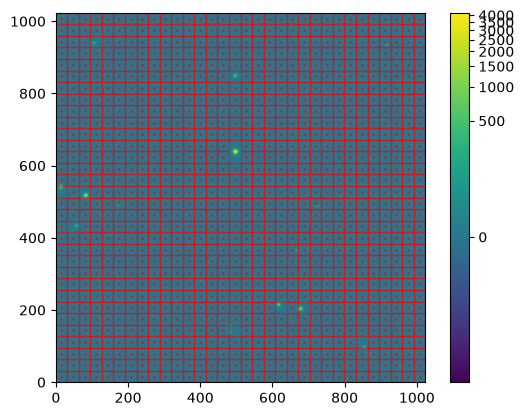

In [6]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

im = ax.imshow(data_clean, origin='lower', norm=simple_norm(data_clean, stretch='log'))

bkg.plot_meshes(ax=ax, marker='.', color='red', alpha=.5, outlines=True, markersize=5,)

fig.colorbar(im)

plt.show()

The mesh looks to be a reasonable size: boxes are larger than individual sources while being small enough to capture variations in the background across the image. Let's now identify the sources in this background-subtracted image:

In [7]:
cat = finder(data_clean, 5 * bkg.background_rms)

cat.pprint_all()

label     x_centroid         y_centroid     sky_centroid bbox_xmin bbox_xmax bbox_ymin bbox_ymax  area   semimajor_axis     semiminor_axis      orientation         eccentricity        min_value          max_value         segment_flux    segment_flux_err     kron_flux      kron_flux_err
                                                                                                  pix2        pix                pix                deg                                                                                                                                       
----- ------------------ ------------------ ------------ --------- --------- --------- --------- ----- ------------------ ------------------ ------------------ ------------------- ------------------ ------------------ ------------------ ---------------- ------------------ -------------
    1  497.6804172508962  638.9789666325404         None       487       509       627       650 388.0 3.3659313208722703 3.256095368794807

As we can see, a number of sources have been identified (22, to be specific). Let's take a look at these sources:

In [8]:
import numpy as np

source_coords = np.asarray([cat['x_centroid'], cat['y_centroid']]).T

semimajor_sigma = np.median(cat['semimajor_axis'].value)
radius = 5 * semimajor_sigma  # aperture radius for plotting

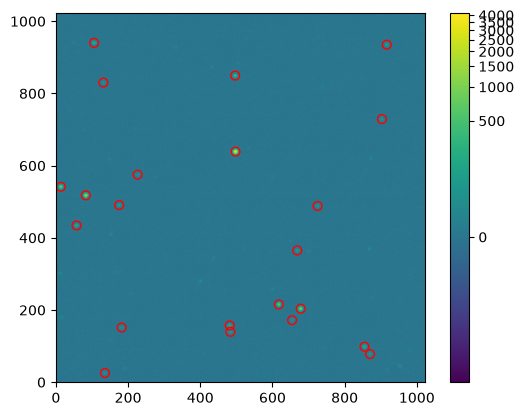

In [9]:
from matplotlib import pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots()

im = ax.imshow(data_clean, origin='lower', norm=simple_norm(data_clean, stretch='log'))

for coords in source_coords:
    ax.add_patch(
        Circle(coords, radius=radius, edgecolor='red', facecolor='none')
    )

fig.colorbar(im)

plt.show()

Source detection looks reasonable. Let's move on to photometry.

For comparison with `Source-Extractor`, we'll only look at aperture photometry. To perform aperture photometry, `opticam` uses the [`photutils.aperture`](https://photutils.readthedocs.io/en/stable/user_guide/aperture.html) subpackage. This subpackage defines convenience routines for defining apertures and performing aperture photometry. For simplicity, we'll use a circular aperture with a 5 pixel radius. By default, `opticam` defines an [`EllipticalAperture`](https://photutils.readthedocs.io/en/stable/api/photutils.aperture.EllipticalAperture.html#photutils.aperture.EllipticalAperture), so we'll make it circular by passing the same value to both axes, and setting the orientation of the ellipse to 0 degrees:

In [10]:
photometer = opticam.AperturePhotometer(
    semimajor_axis=5,
    semiminor_axis=5,
    orientation=0.,
    forced=True,  # use forced photometry since we only have one image
    )

results = photometer.compute(
    image=data_clean,
    bias_var=0.,  # ignore bias variance
    dark_var=0.,  # ignore dark variance
    flat_var=0.,  # ignore flat variance
    background_rms=bkg.background_rms,
    cat_coords=source_coords,
    image_coords=None,  # not needed since forced=True
    psf_params=None,  # not needed since aperture size set manually
    read_noise=0.,  # ignore read noise
    rel_scint_noise=0,  # ignore scintillation noise
    )

fluxes = np.asarray(results['flux'])
flux_errs = np.asarray(results['flux_err'])

One important difference between `opticam`/`photutils` and `Source-Extractor` is how apertures handle partially overlapping pixels. By default, `photutils` (and, by extension, `opticam`) computes the exact fractional overlap of each pixel with the aperture. In contrast, `Source-Extractor` divides pixels into [5x5 subpixels](https://sextractor.readthedocs.io/en/latest/Photom.html#fixed-aperture-flux-flux-aper), and includes subpixels whose centres fall within the aperture. `photutils` can be configured to perform the same subpixelling as `Source-Extractor`, but this is not the default behaviour. As such, `opticam` will generally result in slightly different flux values when compared to `Source-Extractor`.

## `Source-Extractor`

To run `Source-Extractor`, a number of configuration files are required. We therefore need to tweak these configuration files to match the default behaviour of `opticam`. In particular, we need to edit `default.sex` to set `DETECT_MINAREA` to 32, `DETECT_THRESH` and `ANALYSIS_THRESH` to 5, `PHOT_APERTURES` to 10 (since this quantifies the *diameter* of the aperture), and `BACK_SIZE` (background mesh size) to 32. The full configuration file used is given below:

In [11]:
with open(data_path / 'opticam_default.sex', 'r') as file:
    print(file.read())

# Default configuration file for SExtractor V1.2b14 - > 2.0
# EB 23/07/98
# (*) indicates parameters which can be omitted from this config file.

#-------------------------------- Catalog ------------------------------------

CATALOG_NAME	test.cat	# name of the output catalog
CATALOG_TYPE	FITS_1.0	# "NONE","ASCII_HEAD","ASCII","FITS_1.0" or "FITS_LDAC"

PARAMETERS_NAME	opticam_default.param	# name of the file containing catalog contents

#------------------------------- Extraction ----------------------------------

DETECT_TYPE	CCD		# "CCD" or "PHOTO" (*)
FLAG_IMAGE	flag.fits	# filename for an input FLAG-image
DETECT_MINAREA	32		# minimum number of pixels above threshold

THRESH_TYPE	RELATIVE	# threshold type: RELATIVE (in sigmas)
DETECT_THRESH	5		# <sigmas>
ANALYSIS_THRESH	5		# <sigmas>

FILTER		N		# apply filter for detection ("Y" or "N")?
FILTER_NAME	default.conv	# name of the file containing the filter

DEBLEND_NTHRESH	32		# Number of deblending sub-thresholds
DEBLEND_MINCONT	0.1		

I also edited the `default.param` configuration file to only save the following columns in the resulting catalogue:

In [12]:
with open(data_path / 'opticam_default.param', 'r') as file:
    print(file.read())

NUMBER
X_IMAGE
Y_IMAGE
FLUX_APER
FLUXERR_APER


`Source-Extractor` is a command line tool, so it's not as easy as `photutils` to run it in a notebook like this. However, we can use the [`os.system()`](https://docs.python.org/3/library/os.html#os.system) function to pass the required commands to the system shell: 

In [13]:
import os

image_path = data_path.joinpath('V709_Cas_image.fits').resolve()
os.chdir(os.path.join(os.getcwd(), 'sextractor_comparison'))
os.system(f'source-extractor {image_path} -c opticam_default.sex')
os.chdir(os.path.join(os.getcwd(), '..'))  # go back to original directory

> 
----- Source Extractor 2.28.0 started on 2026-06-16 at 11:33:16 with 1 thread

> Setting catalog parameters
> Initializing catalog
> Looking for V709_Cas_image.fits
----- Measuring from: V709_Cas_image.fits
      "v709_cas" / no ext. header / 1024x1024 / 16 bits (integers)
Detection+Measurement image: > Setting up background maps
> Filtering background map(s)
> Computing background d-map
> Computing background-noise d-map
(M+D) Background: 117.514    RMS: 7.8876     / Threshold: 39.438     
> Scanning image
> Line:   25  Objects:        0 detected /        0 sextracted
> Line:   50  Objects:        1 detected /        0 sextracted
> Line:   75  Objects:        1 detected /        0 sextracted
> Line:  100  Objects:        2 detected /        0 sextracted
> Line:  125  Objects:        3 detected /        0 sextracted
> Line:  150  Objects:        4 detected /        0 sextracted
> Line:  175  Objects:        6 detected /        0 sextracted
> Line:  200  Objects:        7 detected / 

We can see that 22 sources were detected, just like `photutils`. We can also see that the image background was 117.514 with an RMS of 7.8876. Let's compare these values to those computed by `photutils`:

In [14]:
print(round(bkg.background_median, 3), round(bkg.background_rms_median, 4))

117.535 7.8861


The background values are extremely similar, as we would hope. Slight differences are likely due to different sigma clipping parameters. `Source-Exractor` will iteratively clip pixels within a mesh box [until all pixels are within $3 \sigma$ of the median value](https://sextractor.readthedocs.io/en/latest/Background.html#background-estimation). By default, `photutils` (and, by extension, `opticam`) uses the same sigma clipping threshold, but only performs [up to 10 iterations](https://photutils.readthedocs.io/en/stable/user_guide/background.html#d-background-and-noise-estimation). Since `photutils` uses an [`astropy.stats.SigmaClip`](https://docs.astropy.org/en/stable/api/astropy.stats.SigmaClip.html#astropy.stats.SigmaClip) instance to perform sigma clipping, it can be configured to clip until convergence is acheived, as in `Source-Extractor`, by defining a `SigmaClip` instance with `maxiters=None`. However, this is not the default behaviour. As such, `opticam` will generally result in slightly different background values when compared to `Source-Extractor`.

Let's now take a look at the resulting catalogue:

In [15]:
from astropy.table import Table

sextractor_cat = Table.read(data_path / 'test.cat', format="fits")
sextractor_cat.sort('FLUX_APER', reverse=True)

sextractor_cat.pprint()

  NUMBER     X_IMAGE     Y_IMAGE    FLUX_APER   FLUXERR_APER
               pix         pix          ct           ct     
---------- ----------- ----------- ------------ ------------
         7    498.6823    639.9772     151779.8     395.8028
        10     83.9666    518.7689     68195.27     270.3383
        16    679.1282    204.6347     44607.61     222.4695
         9     14.7341    542.3884     38965.54     209.3935
        15    618.7043    216.4675      32732.8     194.0046
         4    497.7347    850.5096     19265.88     155.4618
         2    106.8367    941.2122     12632.92     132.3461
        13     58.2004    435.2825     11839.58     129.2564
        21    856.0100     99.3910     11569.81     128.2183
       ...         ...         ...          ...          ...
        14    669.6926    366.0947     5938.621     104.1445
        20    484.3595    140.5544     5709.391     102.9777
        12    725.9660    489.1685     4928.967     99.07835
         6    904.3840  

We can see that we have the coordinates of each detected source as well as the measured flux values and their corresponding errors. Let's see how the detected sources compare to those of `photutils`:

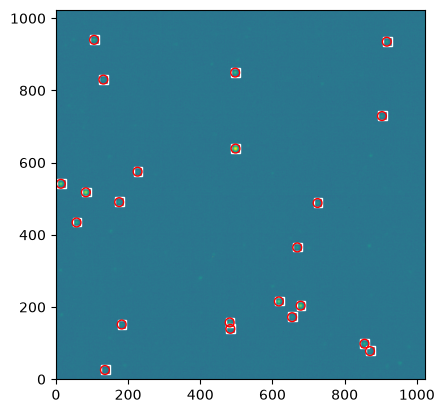

In [16]:
from matplotlib.patches import Rectangle

sextractor_coords = np.asarray([sextractor_cat['X_IMAGE'], sextractor_cat['Y_IMAGE']]).T

fig, ax = plt.subplots()

ax.imshow(data_clean, origin='lower', norm=simple_norm(data_clean, stretch='log'))

for coords in source_coords:
    ax.add_patch(
        Circle(coords, radius=radius, edgecolor='red', facecolor='none')
    )

for coords in sextractor_coords:
    ax.add_patch(
        Rectangle(coords - radius, width=2 * radius, height= 2 * radius, edgecolor='white', facecolor='none', zorder=0)
    )

plt.show()

As we can see, source identification appears identical.

Let's now compare the measured fluxes:

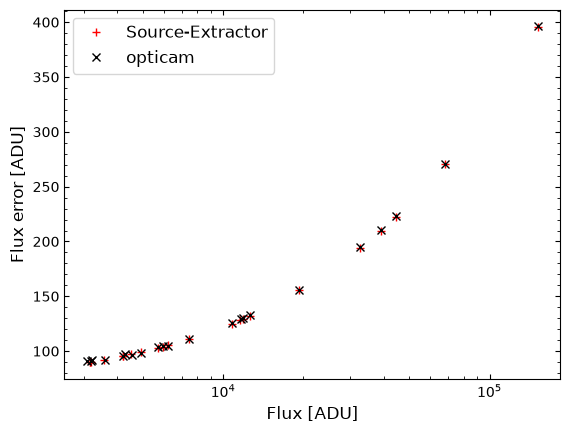

In [17]:
sextractor_fluxes = np.asarray(sextractor_cat['FLUX_APER'])
sextractor_flux_errs = np.asarray(sextractor_cat['FLUXERR_APER'])

fig, ax = plt.subplots()

ax.plot(sextractor_fluxes, sextractor_flux_errs, 'r+', label='Source-Extractor')
ax.plot(fluxes, flux_errs, 'kx', label='opticam')

ax.set_xscale('log')
ax.legend(fontsize='large')

ax.set_ylabel('Flux error [ADU]', fontsize='large')
ax.set_xlabel('Flux [ADU]', fontsize='large')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', right=True, top=True)

plt.show()

Reassuringly, there looks to be very little difference between the two programs. Let's compare the results more quantitatively.

In [18]:
err_ratio = flux_errs / sextractor_flux_errs
print(f'Average error ratio: {err_ratio.mean()}')
print(f'Max err ratio: {err_ratio.max()}')
print(f'Max err ratio: {err_ratio.min()}')
print()

ratio = fluxes / sextractor_fluxes
print(f'Average ratio: {ratio.mean()}')
print(f'Max ratio: {ratio.max()}')
print(f'Min ratio: {ratio.min()}')

Average error ratio: 1.005002830885876
Max err ratio: 1.0260424921219518
Max err ratio: 0.9893920036519251

Average ratio: 1.0009324631316407
Max ratio: 1.0257912595904741
Min ratio: 0.9766904198791279


As we can see, `opticam` (using `photutils`) performs very similarly to `Source-Extractor` when both are configured similarly. On average, the difference between `opticam`/`photutils` and `Source-Extractor` was less than 1% in this example, with extremes of $\sim 2.5$%. As noted above, this difference is due to a combination of how `opticam` and `Source-Extractor` treat partially overlapping pixels differently, and use different sigma clipping parameters.

In [19]:
assert np.isclose(err_ratio.mean(), 1., rtol=0.01, atol=0.)
assert np.isclose(ratio.mean(), 1., rtol=0.01, atol=0.)

That concludes this comparison between `opticam` and `Source-Extractor`.